In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Analyzing the Impact of Weather on Delhi's Air Quality

## 1. Introduction and Problem Formulation
Delhi, the capital territory of India, consistently ranks among the most polluted cities globally. High concentrations of particulate matter (PM2.5 and PM10) pose a severe public health crisis, leading to respiratory and cardiovascular emergencies. 

While the *sources* of this pollution are well-documented (vehicular emissions, crop stubble burning, construction dust), **meteorological conditions** are the primary catalyst for severe smog events. Factors like wind speed, humidity, and temperature inversions dictate whether pollutants disperse into the upper atmosphere or become trapped at ground level.

### Project Objectives and Scope
This technical report explores the intersection of meteorology and urban pollution. To ensure a good analysis, this project uses **two independent data sources**:
1. **Air Quality Data:** Historical daily readings of pollutants and AQI from the Central Pollution Control Board (CPCB).
2. **Historical Weather Data:** Meteorological metrics including temperature, humidity, and wind speed.

**Our primary goals are to:**
1. Ingest, clean, and chronologically merge these two disparate datasets.
2. Perform Data Analysis to uncover statistical correlations between weather phenomena and hazardous AQI spikes.
3. Build a predictive data model to forecast air quality risks based on impending weather conditions.

In [6]:
# Load datasets
df_air_all_cities = pd.read_csv('../data/air_quality.csv')
df_weather = pd.read_csv('../data/delhi_weather.csv')

# We only want Delhi data to match our weather dataset
df_air = df_air_all_cities[df_air_all_cities['City'] == 'Delhi'].copy()

# Verify successful loading
print(f"Air Quality Data (Delhi only) Shape: {df_air.shape}")
print(f"Weather Data Shape: {df_weather.shape}\n")

print("--- First 3 rows of Air Quality Data ---")
display(df_air.head(3))

print("\n--- First 3 rows of Weather Data ---")
display(df_weather.head(3))

Air Quality Data (Delhi only) Shape: (2009, 16)
Weather Data Shape: (96432, 25)

--- First 3 rows of Air Quality Data ---


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
10229,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,41.68,14.36,24.86,9.84,472.0,Severe
10230,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,29.97,10.55,20.09,4.29,454.0,Severe
10231,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,19.71,3.91,10.23,1.99,143.0,Moderate



--- First 3 rows of Weather Data ---


,date_time,maxtempC,mintempC,totalSnow_cm,sunHour,uvIndex,uvIndex.1,moon_illumination,moonrise,moonset,...,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph
0,2009-01-01 00:00:00,22,9,0.0,8.7,4,1,31,10:11 AM,09:57 PM,...,14,19,0,50,0.0,1016,10,10,331,12
1,2009-01-01 01:00:00,22,9,0.0,8.7,4,1,31,10:11 AM,09:57 PM,...,13,21,0,51,0.0,1016,10,10,329,13
2,2009-01-01 02:00:00,22,9,0.0,8.7,4,1,31,10:11 AM,09:57 PM,...,12,22,0,52,0.0,1016,9,10,327,13


## 2. Data Processing and time alignment

A common challenge in data science is integrating datasets with different granularities. 
* Our **Air Quality (AQI)** data is recorded at a **daily** level.
* Our **Weather** data is recorded at an **hourly** level.

To build a unified dataset, we must perform time alignment. We will extract the date from the hourly weather timestamps, group the weather data by day, and calculate the daily mean for each meteorological metric. Once both datasets share a uniform daily index, we can perform an inner join to merge them.

In [7]:
# 1. Standardize Dates in Air Quality Data
df_air['Date'] = pd.to_datetime(df_air['Date'])

# 2. Standardize Dates in Weather Data
# We convert date_time to just date, so we can group it by day.
df_weather['date_time'] = pd.to_datetime(df_weather['date_time'])
df_weather['Date'] = df_weather['date_time'].dt.normalize()

# 3. Aggregate Weather Data to Daily Averages
# We group by the new 'Date' column and calculate the mean for numeric weather metrics
daily_weather = df_weather.groupby('Date').mean(numeric_only=True).reset_index()

# 4. Merge the Datasets
# We perform an 'inner' merge, meaning we only keep days where we have BOTH weather and AQI data
df_merged = pd.merge(df_air, daily_weather, on='Date', how='inner')

# 5. Handle Missing Values
# In time-series environmental data, small gaps are common due to sensor downtime.
# We use linear interpolation to estimate missing values based on surrounding days.
# We select only the numeric columns so we don't crash on text columns like 'AQI_Bucket'
numeric_cols = df_merged.select_dtypes(include=[np.number]).columns
df_merged[numeric_cols] = df_merged[numeric_cols].interpolate(method='linear')

# Drop any remaining NaNs that couldn't be interpolated (like the very first row)
df_merged.dropna(inplace=True)

print(f"Final Merged Dataset Shape: {df_merged.shape}")
print("\n--- First 3 rows of Merged Data ---")
display(df_merged.head(3))

Final Merged Dataset Shape: (1817, 36)

--- First 3 rows of Merged Data ---


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,WindChillC,WindGustKmph,cloudcover,humidity,precipMM,pressure,tempC,visibility,winddirDegree,windspeedKmph
0,Delhi,2015-01-01,313.22,607.98,69.16,36.39,110.59,33.85,15.20,9.25,...,16.375000,9.958333,13.291667,38.875000,0.000000,1017.125,14.958333,10.000,66.750000,5.875000
1,Delhi,2015-01-02,186.18,269.55,62.09,32.87,88.14,31.83,9.54,6.65,...,12.958333,15.500000,62.375000,66.333333,0.008333,1019.250,12.791667,8.875,96.625000,9.916667
2,Delhi,2015-01-03,87.18,131.90,25.73,30.31,47.95,69.55,10.61,2.65,...,15.083333,7.500000,41.375000,83.500000,0.000000,1018.375,13.833333,9.000,123.083333,4.541667


## 3. Exploratory Data Analysis (EDA): Finding the Culprit

With our datasets successfully merged and cleaned, we can now investigate the mathematical relationships between weather conditions and air pollution. 

The most effective way to identify these relationships across multiple variables simultaneously is by calculating a **Correlation Matrix** and visualizing it as a heatmap. A correlation coefficient ranges from -1 to 1:
* **Negative Correlation (closer to -1):** As one variable goes up, the other goes down. (e.g., We expect high wind speed to correlate with lower pollution because it blows the smog away).
* **Positive Correlation (closer to 1):** Both variables move in the same direction. (e.g., We might see a positive correlation between humidity and AQI, as moisture can trap particulates in the air).
* **Zero Correlation (around 0):** No relationship at all.

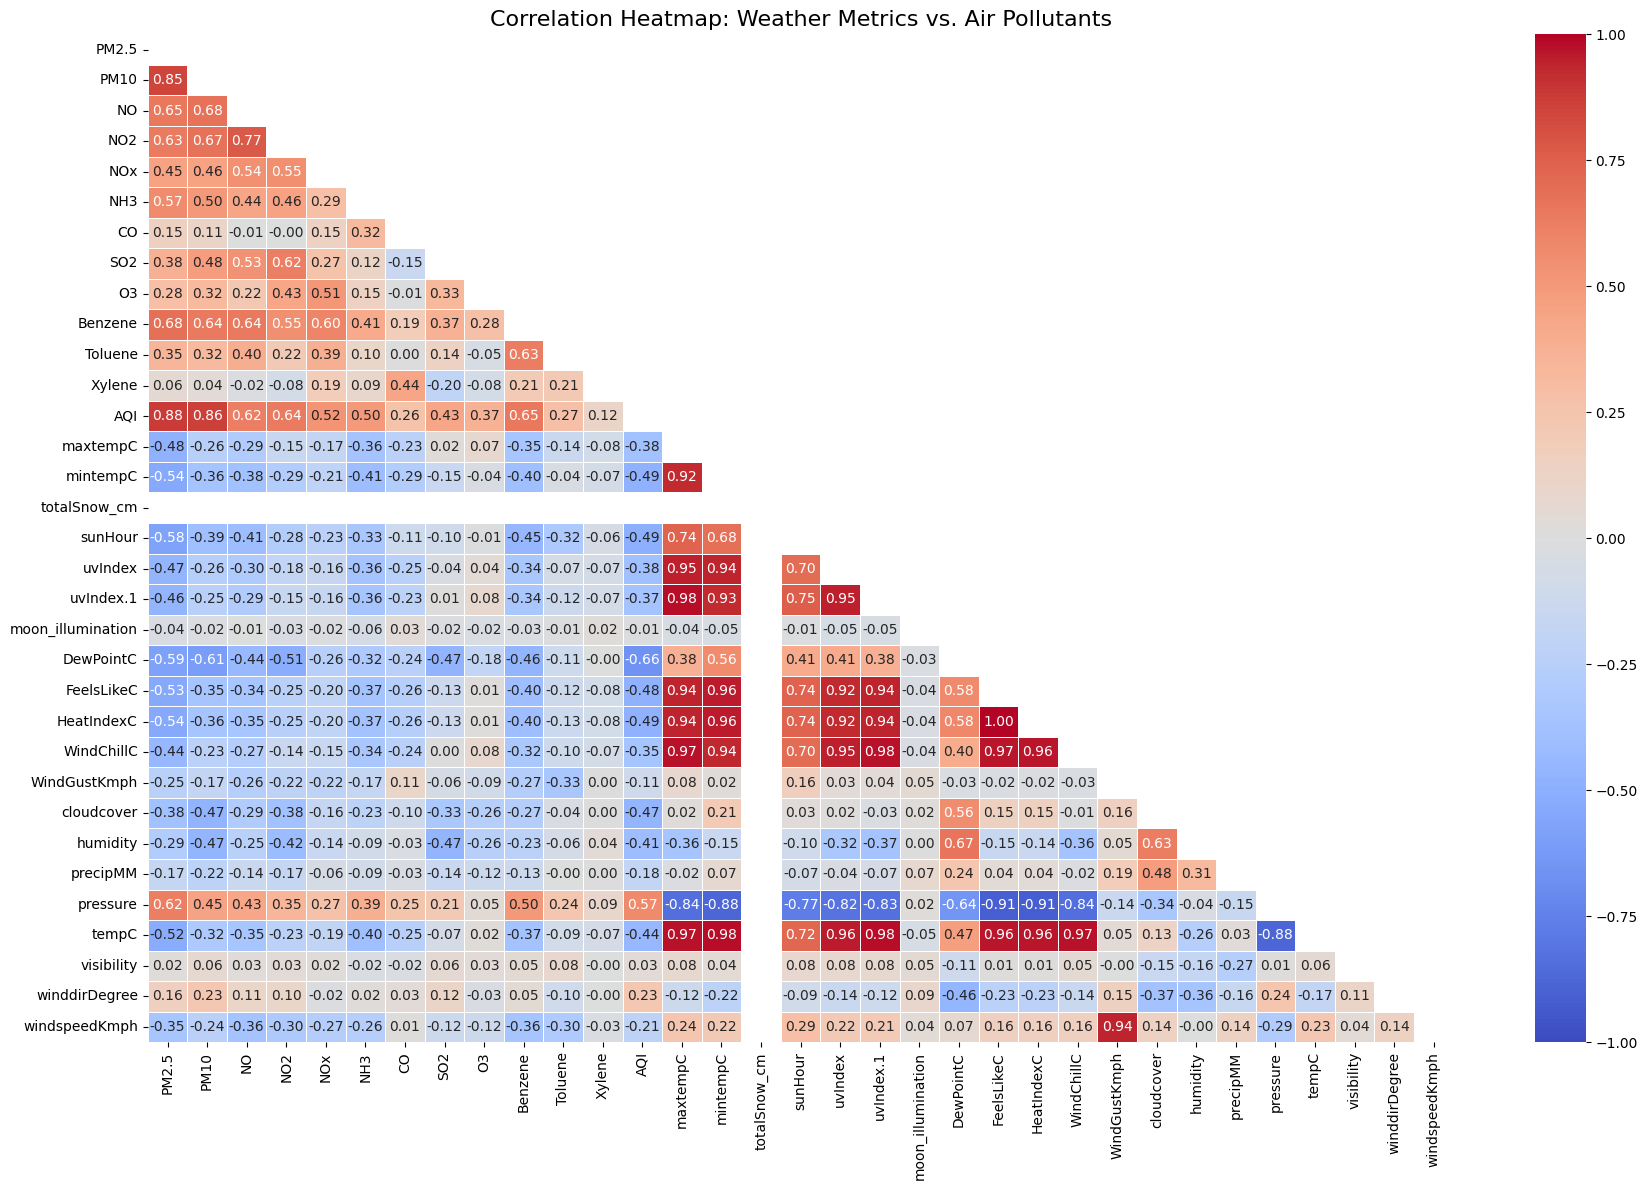

In [8]:
# 1. Isolate the numeric columns for correlation math
numeric_df = df_merged.select_dtypes(include=[np.number])

# 2. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 3. Create a mask to hide the upper triangle.
# We do that because in an unmasked heatmap the top right half is a perfect mirror image to the bottom left half.
# This happens because the matrix compares every single variable agains every other variable.
# So it will compare Temperature and AQI and AQI and Temperature, but their correlation is exactly the same.
# This mask removes the duplicate comparison + the diagonal of perfect correlation.
# This is because the matrix is comparing Temperature to Temperature, Wind to Wind, etc.
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(18, 12))

# 4. Draw the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',   # Red = Positive correlation, Blue = Negative
    vmin=-1, vmax=1,   # Sets the scale from -1 to 1
    center=0,
    linewidths=.5
)

plt.title("Correlation Heatmap: Weather Metrics vs. Air Pollutants", fontsize=16)
plt.tight_layout()
plt.show()

### 3.1 Zooming In: Temperature vs. Particulate Matter (PM2.5)

The correlation heatmap revealed a notable negative correlation between **Temperature** and **PM2.5** levels. In environmental science, this is often linked to a phenomenon called *thermal inversion*. During winter months, cold air is trapped close to the ground by a layer of warmer air above it. This acts like a lid, preventing vehicular and industrial emissions from dispersing.

To visualize this relationship, we will plot Temperature against PM2.5 using a scatter plot and a trendline.

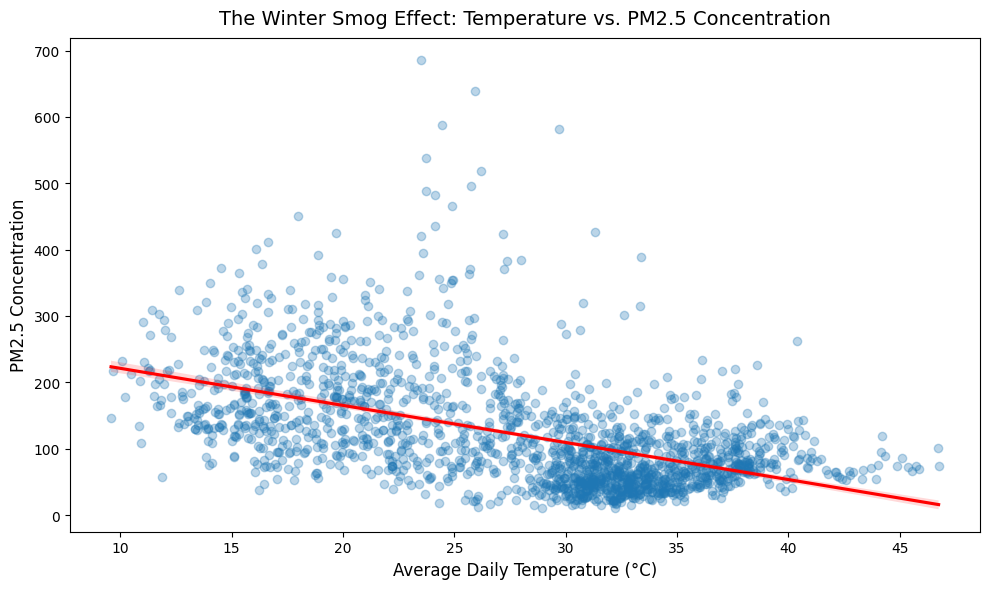

In [9]:
plt.figure(figsize=(10, 6))

# Use Seaborn's regplot to draw the scatter points and a trendline
sns.regplot(
    x='tempC',
    y='PM2.5',
    data=df_merged,
    scatter_kws={'alpha': 0.3},  # Make dots somewhat transparent so we can see density
    line_kws={'color': 'red'}
)

# Add professional labels and titles
plt.title('The Winter Smog Effect: Temperature vs. PM2.5 Concentration', fontsize=14, pad=10)
plt.xlabel('Average Daily Temperature (°C)', fontsize=12)
plt.ylabel('PM2.5 Concentration', fontsize=12)

plt.tight_layout()
plt.show()

### 3.2 Time-Series Analysis: The Seasonal Cycle

Pollution in Delhi is not a static problem; it is highly seasonal. While our scatter plot showed a general inverse relationship, visualizing these metrics chronologically over the course of a year paints a much clearer picture.

To do this, we will extract the "Month" from our timestamps, group the data, and calculate the average PM2.5 and average Temperature for each month. We will then plot them on a dual-axis chart to see exactly when the "smog season" begins and ends.

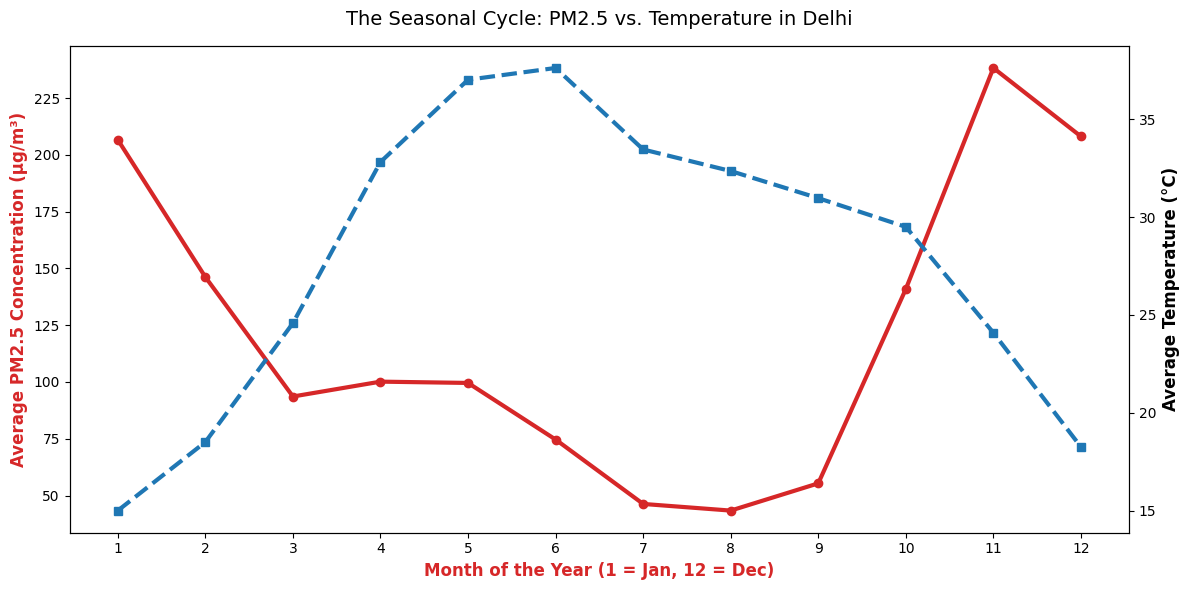

In [17]:
# 1. Extract the month from our Date column
df_merged["Month"] = df_merged["Date"].dt.month

# 2. Group by Month and calculate the mean for PM2.5 and temperature
monthly_data = df_merged.groupby('Month')[['PM2.5', 'tempC']].mean().reset_index()

# Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(12, 6))

color1 = 'tab:red'
ax1.set_xlabel('Month of the Year (1 = Jan, 12 = Dec)', color=color1, fontsize=12, fontweight='bold')
ax1.set_ylabel('Average PM2.5 Concentration (µg/m³)', color=color1, fontsize=12, fontweight='bold')
ax1.plot(monthly_data['Month'], monthly_data['PM2.5'], color=color1, marker='o', linewidth=3, label='PM2.5')
ax1.grid(False)

# Make a second Y axis, sharing the same X axis
ax2 = ax1.twinx()

ax2.set_ylabel('Average Temperature (°C)', fontsize=12, fontweight='bold')
ax2.plot(monthly_data['Month'], monthly_data['tempC'], marker='s', linewidth=3, linestyle='--', label='Temperature')
ax2.tick_params(axis='y')
ax2.grid(False)

plt.title('The Seasonal Cycle: PM2.5 vs. Temperature in Delhi', fontsize=14, pad=15)
plt.xticks(range(1, 13)) # Ensure all 12 months show up on the bottom
fig.tight_layout()  # Prevents labels from getting cut off

plt.show()

## 4. Feature Engineering for Machine Learning

Before feeding our data into a predictive model, we need to engineer new features that provide temporal context. A machine learning algorithm looks at one row at a time. If we only give it "today's temperature", it doesn't know if a cold front just moved in or if it's been cold all week.

We will create three new contextual features:
1. **Lagged PM2.5 (`PM2.5_Yesterday`):** The pollution level from the previous day. Smog accumulates, so yesterday's air quality is a massive predictor of today's air quality.
2. **Temperature Change (`Temp_Change`):** The difference in temperature between yesterday and today. Sudden drops can trigger thermal inversions.
3. **Rolling Average (`PM2.5_3Day_Avg`):** A 3-day moving average to smooth out daily anomalies and capture the immediate trend.

In [20]:
# 1. Create Lagged Feature (Shift the PM2.5 column down by 1 row)
df_merged['PM2.5_Yesterday'] = df_merged['PM2.5'].shift(1)

# 2. Create Difference Feature (Today's temp minus Yesterday's temp)
df_merged['Temp_Change'] = df_merged["tempC"] - df_merged["tempC"].shift(1)

# 3. Create Rolling Window Feature (Average of the last 3 days)
df_merged['PM2.5_3Day_Avg'] = df_merged['PM2.5'].rolling(window=3).mean()

# Because we shifted data down by 1 to 3 days, the first 2 rows of our dataset 
# will now have NaN (missing) values since they have no "yesterday" to look back at.
# We must drop these new NaNs before doing machine learning.
df_merged.dropna(inplace=True)

# Let's look at our newly engineered columns to ensure the math worked!
feature_check_cols = ['Date', 'PM2.5', 'PM2.5_Yesterday', 'tempC', 'Temp_Change', 'PM2.5_3Day_Avg']
print("--- Engineered Features ---")
display(df_merged[feature_check_cols].head(5))

--- Engineered Features ---


,Date,PM2.5,PM2.5_Yesterday,tempC,Temp_Change,PM2.5_3Day_Avg
6,2015-01-07,217.87,149.58,12.208333,-0.791667,171.350000
7,2015-01-08,229.90,217.87,11.083333,-1.125000,199.116667
8,2015-01-09,201.66,229.90,10.875000,-0.208333,216.476667
9,2015-01-10,221.02,201.66,11.250000,0.375000,217.526667
10,2015-01-11,205.41,221.02,11.750000,0.500000,209.363333
